In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ctxbandit import PolicyInferenceJoint

In [ ]:
num_arms = 10 
context_dim = 12

size_inference = 1024
seed_inference = 11235813

size_learning_baseline = 256
seed_learning_baseline = 31415926

scale_se, power_ub, num_arms_top = 1, 2, 3
policy_param_baseline = scale_se, power_ub, num_arms_top

size_learning_new = 1024
seed_learning_new = 31415926

scale_se, power_ub, num_arms_top = 1, 1, 1
policy_param_new = scale_se, power_ub, num_arms_top

inference = PolicyInferenceJoint(
    num_arms, context_dim, 
    size_inference, seed_inference, 
    size_learning_baseline, seed_learning_baseline, policy_param_baseline, 
    size_learning_new, seed_learning_new, policy_param_new, 
)

### Compute Policy Value by MC Integration

In [ ]:
inference.compute_policy_value_by_mc_integration(
    repeat=100, size_per_repeat=1000,    # use a small MC sample size for demonstration
    seed=31415926, verbose=True, 
)

Policy value by Monte Carlo integration
    0.07636457 (difference)
    0.7546347 (baseline)
    0.8309993 (new)
    0.838117 (oracle)
Parameters
    MC sample size: 100,000 (100 repetitions of subsample size 1,000 each)
    Random seed: 31415926
Runtime
    0:00:01.7



In [ ]:
print(inference.mc_result)

policy_value_vector: (0.7546347, 0.8309993)
policy_value_difference: 0.07636457
policy_value_baseline: 0.7546347
policy_value_new: 0.8309993
policy_value_oracle: 0.838117
runtime: 1.738727
parameters:
    mc_sample_size: 100,000
    repeat: 100
    size_per_repeat: 1,000
    seed: 31,415,926


### Compute MLE

In [ ]:
size = 16
inference.compute_mle(size)
mle_result = inference.mle_result_by_size[size]
print(mle_result)

joint:
    mle: [0.7660109, 0.9527439]
    unique: False
    mle_observed: [0.6838969, 0.9054878]
    interval: ([0.6838969, 0.9054878], [0.848125, 1])
    region: ([0.6838969, 0.9054878], [0.7784091, 1], [0.848125, 1], [0.7536128, 0.9054878])
difference:
    mle: 0.186733
    unique: False
    mle_observed: 0.2215909
    interval: (0.151875, 0.2215909)
max_log_elr: -0.4968843
beta_star: [-0.1111111, -1.407537e-10]
unobserved_extreme: ([0, 10], [10, 0], [10, 10])
unobserved_extreme_with_weight: ([10, 0], [10, 10])
unobserved_extreme_with_weight_excluding_0: ([10, 0], [10, 10])
solver_index: 0
runtime: 0.007865474


### Importance Dataset Used for Inference

In [ ]:
importance_dataset = inference.importance_dataset_by_size[size]
print(importance_dataset, '\n')

print(
    np.column_stack((
        importance_dataset.c, 
        importance_dataset.ww, 
        importance_dataset.r, 
    ))
)

c: ndarray of shape (4,)
ww: ndarray of shape (4, 2)
r: ndarray of shape (4,) 

[[13.          0.          0.          0.        ]
 [ 1.          3.77358491  0.          1.        ]
 [ 1.          2.12598425  0.          0.        ]
 [ 1.          3.78787879 10.          1.        ]]


### Compute Empirical Likelihood Ratio over Grid

In [ ]:
inference.compute_elr_over_grid(size, num_points=100, verbose=True)
grid_result = inference.grid_result_by_size[size]

Completed computing the empirical likelihood ratio over a grid
    Parameters
        Importance dataset size: 16
        Number of grid points: 10,000
        Wilks level for adaptive support: 0.9999
        Parallel computing: True
            num_processes: 4
            maxtasksperchild: None
            chunksize: 625
            num_chunks: 16
    Runtime
        wilks_bound: 0:00:00
        elr_on_grid: 0:00:02
        total:       0:00:02



In [ ]:
print(grid_result)

grid_0: ndarray of shape (100, 100)
grid_1: ndarray of shape (100, 100)
elr_on_grid: ndarray of shape (100, 100)
solver_index_on_grid: ndarray of shape (10000,)
grid: ndarray of shape (100, 100, 2)
step_size_0: 0.009969582
step_size_1: 0.009999299
adaptive_support:
    bound_0: (0.003036013, 0.9999942)
    bound_1: (7.01466e-05, 1)
    width_0: 0.9969582
    width_1: 0.9999299
    elr_cutoff: 6.084234e-05
    wilks_level: 0.9999
    solver_index_0: (0, 0)
    solver_index_1: (0, 0)
    runtime: 0.02976651
runtime:
    wilks_bound: 0.02976651
    elr_on_grid: 1.983562
    total: 2.013328


### Compute $\mathbb{P}$(improvement)

In [ ]:
inference.compute_prob_improvement(size, mode="abs", margin=0.)
inference.compute_prob_improvement(size, mode="abs", margin=0.05)
inference.compute_prob_improvement(size, mode="abs", margin=0.1)
inference.compute_prob_improvement(size, mode="rel", margin=0.)
inference.compute_prob_improvement(size, mode="rel", margin=0.05)
inference.compute_prob_improvement(size, mode="rel", margin=0.1)

prob_improvement_result = inference.prob_improvement_result_by_size[size]
print(prob_improvement_result)

abs_margin_to_prob:
    0.0: 0.6085223
    0.05: 0.5328234
    0.1: 0.4538534
rel_margin_to_prob:
    0.0: 0.6085223
    0.05: 0.5689873
    0.1: 0.5245103


### Plot

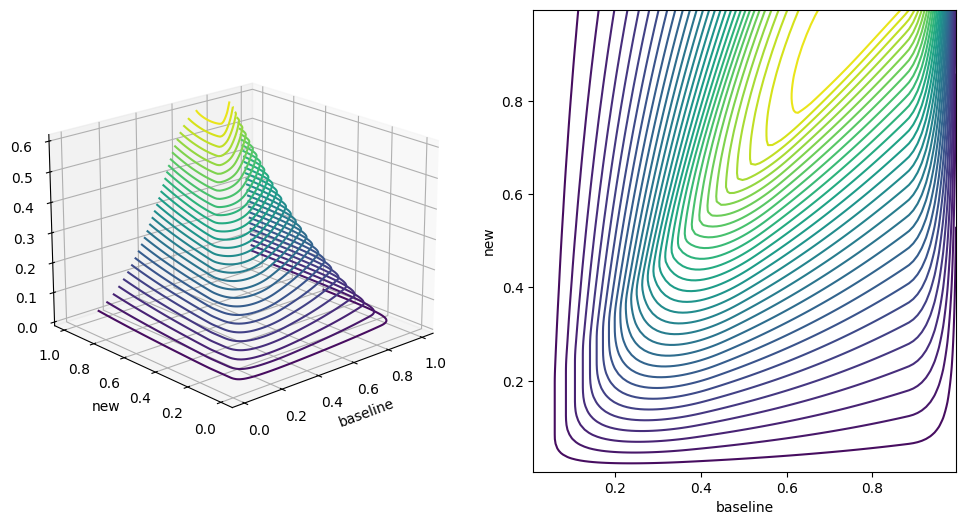

In [ ]:
grid_result = inference.grid_result_by_size[size]
X = grid_result.grid_0
Y = grid_result.grid_1
Z = grid_result.elr_on_grid

fig = plt.figure(figsize=(12,6))

ax = fig.add_subplot(1, 2, 1, projection='3d')
ax.contour3D(X, Y, Z, 30, cmap='viridis')
ax.set_xlabel('baseline'); ax.set_ylabel('new'); ax.set_zlabel('')
ax.view_init(20, -132)

ax = fig.add_subplot(1, 2, 2)
ax.contour(X, Y, Z, 30, cmap='viridis')
ax.set_xlabel('baseline'); ax.set_ylabel('new')

plt.show()